In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

In [2]:
df_train_clean = pd.read_csv("../../data/processed/01.3/accidents_advance_clean.csv")

df_train_clean.head(10)

,Severity,Start_Time,Start_Lat,Start_Lng,Distance(mi),Description,Street,City,County,State,...,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Duration(min),Start_Date,Hour,Month,Weather_Group
0,3,2016-11-08 08:50:37,29.718655,-95.321053,0.009950,Accident on I-45 Northbound at I-45 Exits 43A ...,I-45 N,Houston,Harris,TX,...,False,Day,Day,Day,Day,3.405079,2016-11-08,8,11,Cloudy
1,2,2021-07-26 07:04:56,38.927551,-121.080093,0.000000,Right hand shoulder blocked due to accident on...,Taylor Ln,Auburn,Placer,CA,...,False,Day,Day,Day,Day,3.862833,2021-07-26,7,7,Clear
2,2,2018-10-24 08:23:38,34.776241,-86.672829,0.000000,Lane blocked due to accident on AL-255 Researc...,Highway 255,Huntsville,Madison,AL,...,False,Day,Day,Day,Day,3.422633,2018-10-24,8,10,Clear
3,3,2019-07-11 10:42:48,42.384880,-83.149467,0.470004,Entry ramp to I-96 Westbound from Davison West...,Edward J Jeffries Fwy,Detroit,Wayne,MI,...,False,Day,Day,Day,Day,4.784571,2019-07-11,10,7,Clear
4,2,2020-11-06 01:29:00,33.776575,-117.837134,0.387980,1023: NB 55 JNO 22. SV REAR ENDED VV AND WAS L...,Garden Grove Fwy,Orange,Orange,CA,...,False,Night,Night,Night,Night,4.952535,2020-11-06,1,11,Clear
5,2,2021-07-02 15:22:00,36.989497,-121.935657,0.033435,Incident on PARK AVE WB near SOQUEL DR Expect ...,Park Ave N,Soquel,Santa Cruz,CA,...,False,Day,Day,Day,Day,5.758376,2021-07-02,15,7,Cloudy
6,2,2019-08-09 08:44:18,30.419380,-91.096611,0.000000,Accident on LA-73 Jefferson Hwy at LA-3064 Ess...,Essen Ln,Baton Rouge,East Baton Rouge,LA,...,False,Day,Day,Day,Day,4.665638,2019-08-09,8,8,Cloudy
7,2,2021-12-10 07:02:30,33.194519,-111.901301,1.015955,Stationary traffic on I-10 E - Pearl Harbor Me...,I-10 E,Maricopa,Pinal,AZ,...,False,Night,Day,Day,Day,4.248495,2021-12-10,7,12,Clear
8,3,2021-04-26 19:57:38,29.384928,-98.512321,0.000000,Three lanes blocked due to accident on I-35 So...,I-35 N,San Antonio,Bexar,TX,...,False,Day,Day,Day,Day,5.332880,2021-04-26,19,4,Clear
9,2,2017-04-18 19:05:08,26.589575,-81.703766,0.000000,Accident on 25th St at Curtis Ave.,25th St SW,Lehigh Acres,Lee,FL,...,False,Day,Day,Day,Day,3.751463,2017-04-18,19,4,Cloudy


## 1. การกระจายตัวของ Severity (Target Distribution)

`Severity` คือ target variable มี 4 ระดับ:
- **1** = ผลกระทบต่อการจราจรเล็กน้อย
- **2** = กระทบปานกลาง
- **3** = กระทบมาก
- **4** = กระทบรุนแรงมาก

สิ่งที่ต้องสังเกต: **class imbalance** — ถ้า Severity 2 มีสัดส่วนสูงมาก model จะเรียนรู้ bias ไปทาง class นั้น ต้องพิจารณาใช้ class_weight หรือ resampling ตอน train

C:\Users\putte\AppData\Local\Temp\ipykernel_21220\1233991882.py:27: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\1233991882.py:27: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\1233991882.py:27: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\1233991882.py:27: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\1233991882.py:27: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\1233991882.py:27: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) Arial

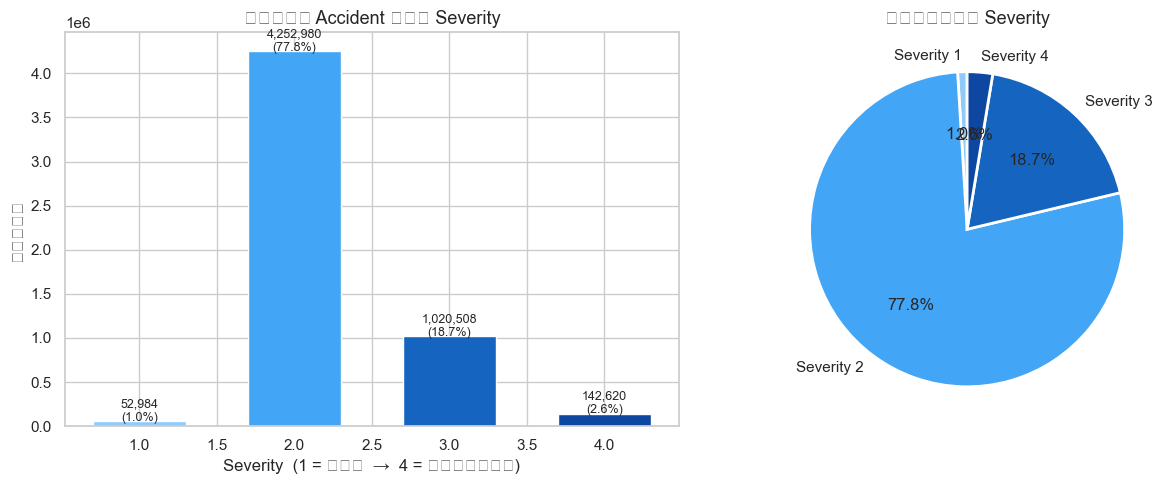

Class imbalance: Severity 2 คิดเป็น 77.8% ของข้อมูลทั้งหมด


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

severity_counts = df_train_clean['Severity'].value_counts().sort_index()
colors_sev = ['#90CAF9', '#42A5F5', '#1565C0', '#0D47A1']

# --- Left: bar chart ---
bars = axes[0].bar(severity_counts.index, severity_counts.values, color=colors_sev, edgecolor='white', width=0.6)
axes[0].set_title('จำนวน Accident ตาม Severity', fontsize=13)
axes[0].set_xlabel('Severity  (1 = เบา  →  4 = หนักมาก)')
axes[0].set_ylabel('จำนวน')
for bar, val in zip(bars, severity_counts.values):
    pct = val / severity_counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5000,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=9)

# --- Right: pie ---
axes[1].pie(
    severity_counts.values,
    labels=[f'Severity {i}' for i in severity_counts.index],
    autopct='%1.1f%%',
    colors=colors_sev,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('สัดส่วน Severity', fontsize=13)

plt.tight_layout()
plt.show()

print(f"Class imbalance: Severity 2 คิดเป็น {severity_counts[2]/severity_counts.sum()*100:.1f}% ของข้อมูลทั้งหมด")

## 2. การวิเคราะห์ตามเวลา (Temporal Analysis)

**ตามชั่วโมง:** ช่วง rush hour เช้า (7–9) และเย็น (16–18) มักมี accident สูงสุด สอดคล้องกับปริมาณรถที่หนาแน่น ช่วงดึก (1–5) มีน้อยสุด

**ตามเดือน:** ดูว่าฤดูกาลมีผลต่อจำนวน accident ไหม — เดือนหนาว (ธ.ค.–ม.ค.) อาจสูงในรัฐทางเหนือ ส่วนฤดูฝนอาจเพิ่มใน FL, TX

C:\Users\putte\AppData\Local\Temp\ipykernel_21220\3049837567.py:26: UserWarning: Glyph 3594 (\N{THAI CHARACTER CHO CHANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\3049837567.py:26: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\3049837567.py:26: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\3049837567.py:26: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\3049837567.py:26: UserWarning: Glyph 3650 (\N{THAI CHARACTER SARA O}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\3049837567.py:26: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) Arial

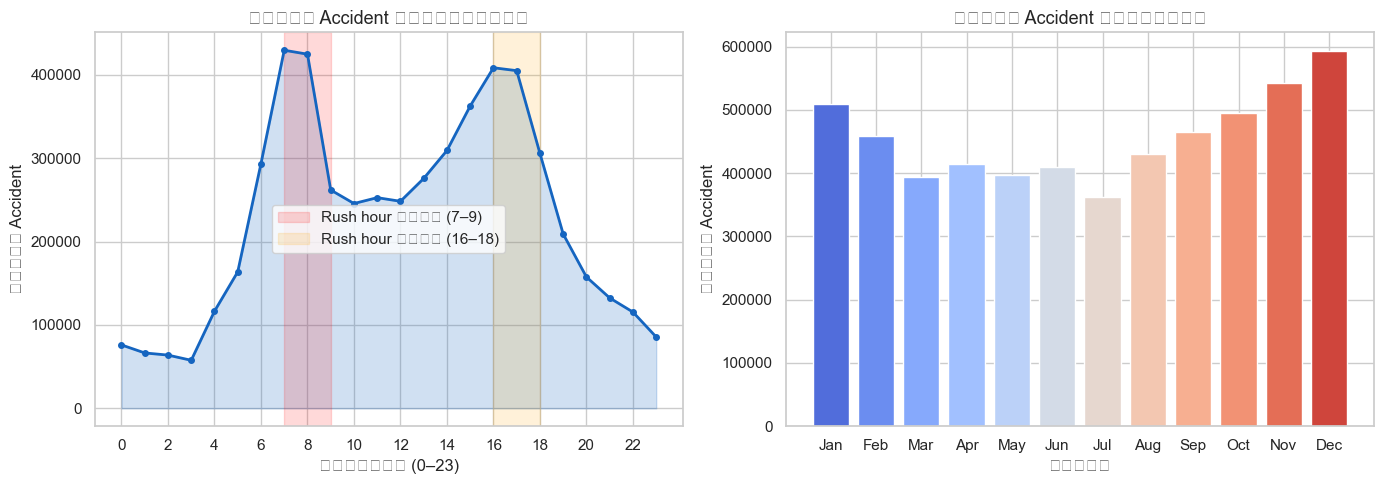

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: accidents by hour ---
hour_counts = df_train_clean['Hour'].value_counts().sort_index()
axes[0].plot(hour_counts.index, hour_counts.values, marker='o', linewidth=2, color='#1565C0', markersize=4)
axes[0].fill_between(hour_counts.index, hour_counts.values, alpha=0.2, color='#1565C0')
axes[0].axvspan(7, 9, alpha=0.15, color='red', label='Rush hour เช้า (7–9)')
axes[0].axvspan(16, 18, alpha=0.15, color='orange', label='Rush hour เย็น (16–18)')
axes[0].set_title('จำนวน Accident ตามชั่วโมง', fontsize=13)
axes[0].set_xlabel('ชั่วโมง (0–23)')
axes[0].set_ylabel('จำนวน Accident')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

# --- Right: accidents by month ---
month_counts = df_train_clean['Month'].value_counts().sort_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bar_colors = sns.color_palette('coolwarm', n_colors=12)
axes[1].bar(month_counts.index, month_counts.values, color=bar_colors, edgecolor='white')
axes[1].set_title('จำนวน Accident ตามเดือน', fontsize=13)
axes[1].set_xlabel('เดือน')
axes[1].set_ylabel('จำนวน Accident')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)

plt.tight_layout()
plt.show()

## 3. กลางวัน/กลางคืน & ภูมิศาสตร์

**Day vs Night:** `Sunrise_Sunset` บอกว่า accident เกิดช่วงไหน — ถ้า Night มี % สูงกว่าสัดส่วนชั่วโมง (8 ชม. กลางคืน vs 16 ชม. กลางวัน) แสดงว่ากลางคืนอันตรายกว่า per hour

**Top 10 States:** รัฐใหญ่ที่มีถนนมากหรือประชากรหนาแน่น (เช่น CA, TX, FL) มักติดอันดับสูง — ควรพิจารณาปรับตาม population หรือ miles of road ถ้าต้องการเปรียบเทียบ rate

C:\Users\putte\AppData\Local\Temp\ipykernel_21220\3785863832.py:25: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\3785863832.py:25: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\3785863832.py:25: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\3785863832.py:25: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\3785863832.py:25: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\3785863832.py:25: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) Aria

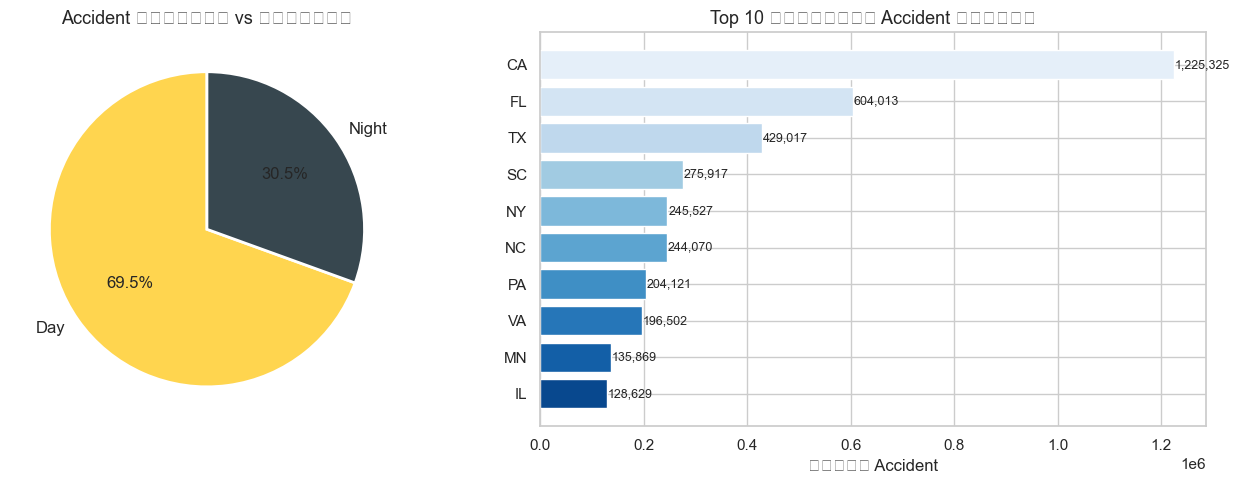

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Day vs Night pie ---
day_night = df_train_clean['Sunrise_Sunset'].value_counts()
axes[0].pie(
    day_night.values,
    labels=day_night.index,
    autopct='%1.1f%%',
    colors=['#FFD54F', '#37474F'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
axes[0].set_title('Accident กลางวัน vs กลางคืน', fontsize=13)

# --- Right: Top 10 states ---
top_states = df_train_clean['State'].value_counts().head(10)
colors_states = sns.color_palette('Blues_r', n_colors=10)
axes[1].barh(top_states.index[::-1], top_states.values[::-1], color=colors_states)
axes[1].set_title('Top 10 รัฐที่มี Accident สูงสุด', fontsize=13)
axes[1].set_xlabel('จำนวน Accident')
for i, val in enumerate(top_states.values[::-1]):
    axes[1].text(val + 2000, i, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 4. สภาพอากาศ (Weather Group)

`Weather_Group` ถูกสร้างจาก notebook 01.3 โดยจัดกลุ่มจาก `Weather_Condition` ดิบที่มี 142 ค่าเป็น 8 กลุ่ม:
**Clear, Cloudy, Rain, Fog, Snow_Ice, Severe, Windy, Other**

กราฟซ้าย: ดูว่า accident ส่วนใหญ่เกิดในสภาพอากาศแบบไหน  
กราฟขวา: ดู average severity ของแต่ละกลุ่ม — กลุ่มที่อยู่เหนือ overall mean (เส้นแดง) บ่งบอกว่าสภาพอากาศนั้นทำให้อุบัติเหตุรุนแรงกว่าค่าเฉลี่ย

C:\Users\putte\AppData\Local\Temp\ipykernel_21220\1260997998.py:33: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\1260997998.py:33: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\1260997998.py:33: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\1260997998.py:33: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\1260997998.py:33: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\1260997998.py:33: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) Arial.
  p

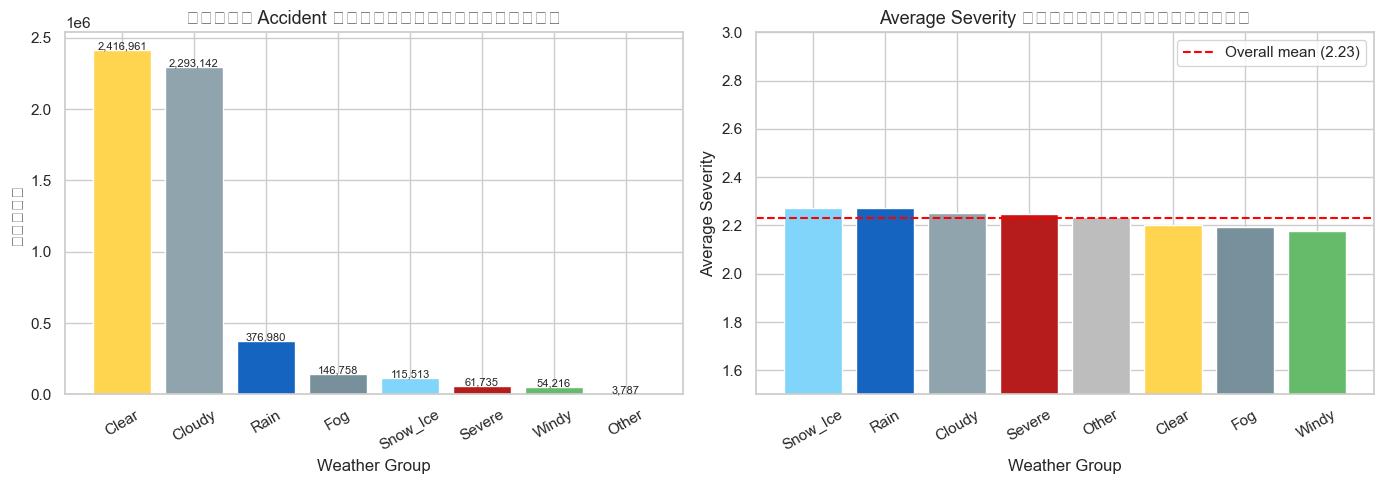

In [6]:
palette = {
    'Clear': '#FFD54F', 'Cloudy': '#90A4AE', 'Rain': '#1565C0',
    'Fog': '#78909C', 'Snow_Ice': '#81D4FA', 'Severe': '#B71C1C',
    'Windy': '#66BB6A', 'Other': '#BDBDBD'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: count per weather group ---
weather_counts = df_train_clean['Weather_Group'].value_counts()
bar_colors = [palette.get(w, '#BDBDBD') for w in weather_counts.index]
axes[0].bar(weather_counts.index, weather_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title('จำนวน Accident ตามกลุ่มสภาพอากาศ', fontsize=13)
axes[0].set_xlabel('Weather Group')
axes[0].set_ylabel('จำนวน')
axes[0].tick_params(axis='x', rotation=30)
for i, (lbl, val) in enumerate(zip(weather_counts.index, weather_counts.values)):
    axes[0].text(i, val + 3000, f'{val:,}', ha='center', fontsize=8)

# --- Right: average severity per weather group ---
avg_sev = df_train_clean.groupby('Weather_Group')['Severity'].mean().sort_values(ascending=False)
bar_colors2 = [palette.get(w, '#BDBDBD') for w in avg_sev.index]
axes[1].bar(avg_sev.index, avg_sev.values, color=bar_colors2, edgecolor='white')
axes[1].axhline(y=df_train_clean['Severity'].mean(), color='red', linestyle='--',
                label=f'Overall mean ({df_train_clean["Severity"].mean():.2f})')
axes[1].set_title('Average Severity ตามกลุ่มสภาพอากาศ', fontsize=13)
axes[1].set_xlabel('Weather Group')
axes[1].set_ylabel('Average Severity')
axes[1].set_ylim(1.5, 3.0)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Weather Numeric Features vs Severity

ค่า weather ทั้งหมดถูก transform แล้วจาก notebook 01.3 ตาม skewness:
- **Temperature, Visibility, Wind_Chill, Pressure** → squared (แก้ left-skew)
- **Wind_Speed** → sqrt (แก้ right-skew ปานกลาง)
- **Precipitation, Distance, Duration** → log1p (แก้ right-skew รุนแรง)

Boxplot ช่วยดูว่า distribution ของแต่ละ feature เปลี่ยนแปลงตาม severity อย่างไร — ถ้า median ต่างกันชัดเจน แสดงว่า feature นั้นมี predictive power

C:\Users\putte\AppData\Local\Temp\ipykernel_21220\320357391.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\320357391.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\320357391.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\320357391.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

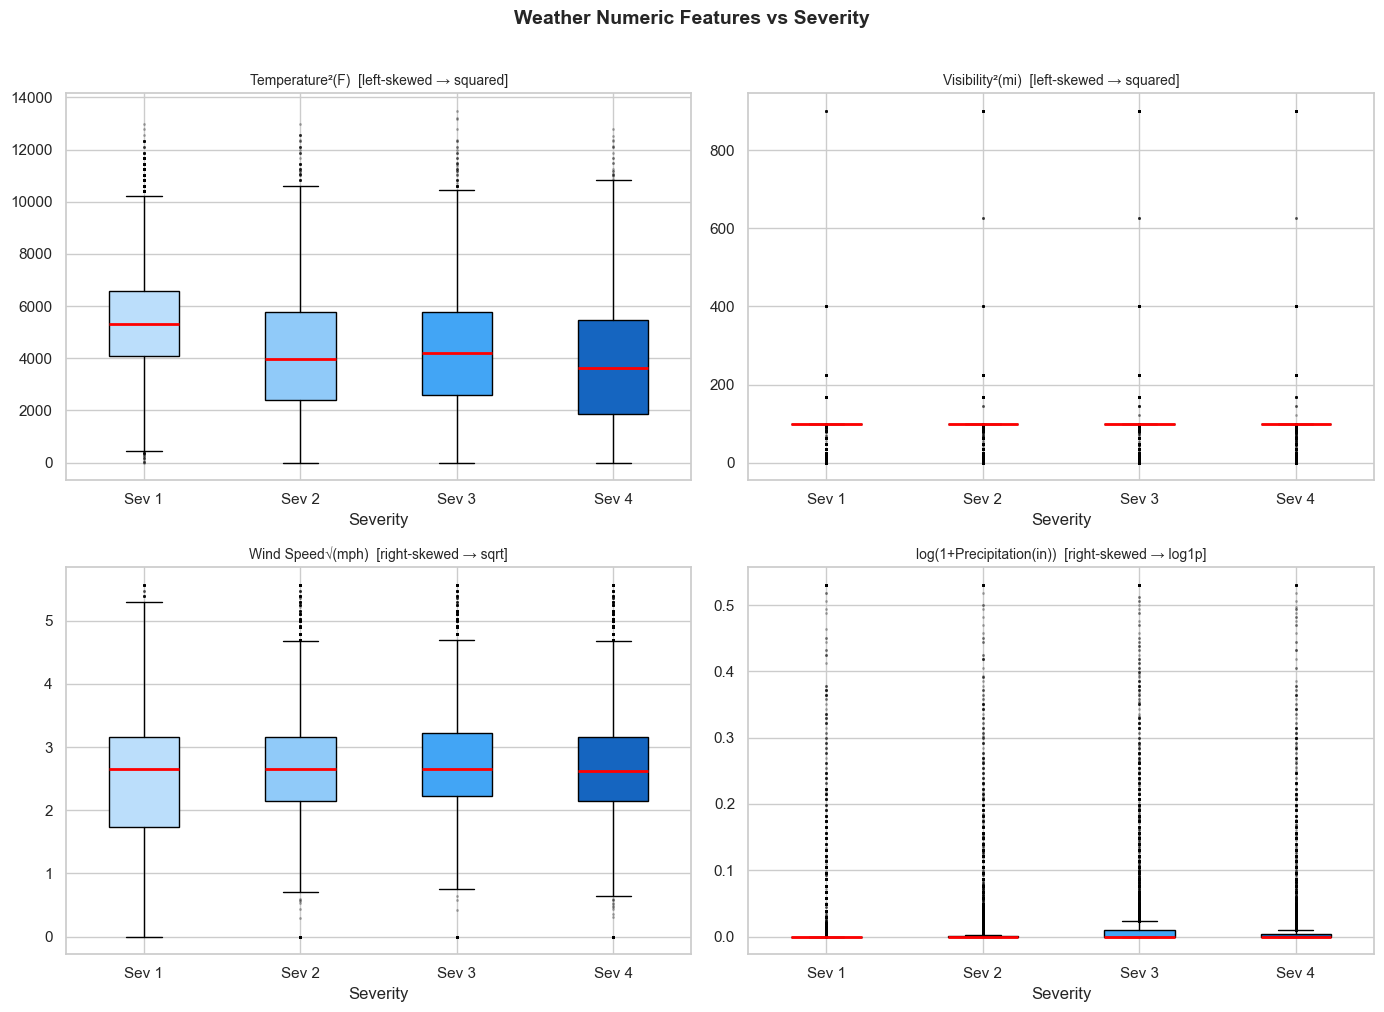

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

weather_features = [
    ('Temperature(F)',   'Temperature²(F)  [left-skewed → squared]'),
    ('Visibility(mi)',   'Visibility²(mi)  [left-skewed → squared]'),
    ('Wind_Speed(mph)',  'Wind Speed√(mph)  [right-skewed → sqrt]'),
    ('Precipitation(in)','log(1+Precipitation(in))  [right-skewed → log1p]'),
]

colors_sev = ['#BBDEFB', '#90CAF9', '#42A5F5', '#1565C0']

for ax, (col, title) in zip(axes.flatten(), weather_features):
    data_by_sev = []
    for s in sorted(df_train_clean['Severity'].unique()):
        subset = df_train_clean[df_train_clean['Severity'] == s][col].dropna()
        n = min(30000, len(subset))
        data_by_sev.append(subset.sample(n, random_state=42))

    bp = ax.boxplot(
        data_by_sev,
        labels=[f'Sev {s}' for s in sorted(df_train_clean['Severity'].unique())],
        patch_artist=True,
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(marker='.', markersize=2, alpha=0.3)
    )
    for patch, color in zip(bp['boxes'], colors_sev):
        patch.set_facecolor(color)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Severity')

plt.suptitle('Weather Numeric Features vs Severity', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. โครงสร้างถนน & ระยะเวลาของ Accident

**Duration(min):** ค่าถูก log-transform ไว้ก่อนหน้า — ค่า median ที่สูงขึ้นตาม Severity บ่งบอกว่า อุบัติเหตุรุนแรงกีดขวางถนนนานกว่า

**Road Infrastructure Heatmap:** แสดง % ของ accident แต่ละ Severity ที่เกิดขึ้นใกล้สิ่งก่อสร้างแต่ละประเภท เช่น `Crossing`, `Junction`, `Traffic_Signal` — ถ้า % สูงใน severity สูง แสดงว่าโครงสร้างนั้นอาจสัมพันธ์กับความรุนแรง

C:\Users\putte\AppData\Local\Temp\ipykernel_21220\2283628883.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\2283628883.py:41: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\2283628883.py:41: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\2283628883.py:41: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\2283628883.py:41: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\putte\AppData\Local\Temp\ipykernel_21220\22836288

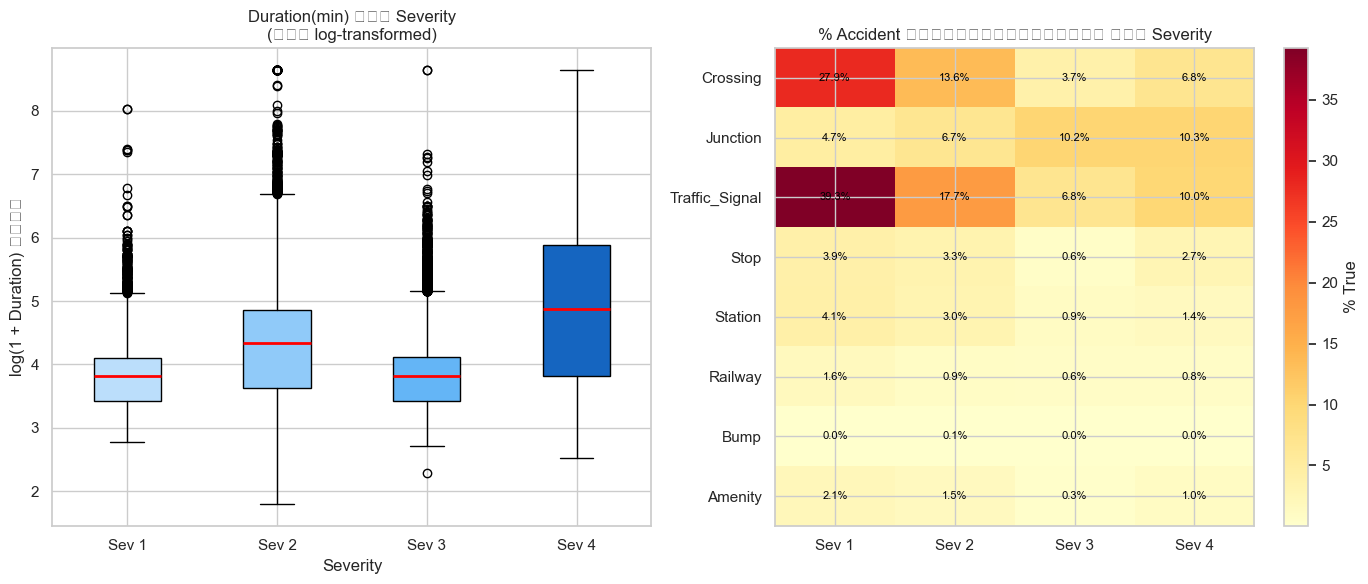

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Duration (log-transformed) by Severity ---
data_dur = [
    df_train_clean[df_train_clean['Severity'] == s]['Duration(min)']
    .dropna()
    .sample(min(30000, (df_train_clean['Severity'] == s).sum()), random_state=42)
    for s in sorted(df_train_clean['Severity'].unique())
]
bp = axes[0].boxplot(
    data_dur,
    labels=[f'Sev {s}' for s in sorted(df_train_clean['Severity'].unique())],
    patch_artist=True,
    medianprops=dict(color='red', linewidth=2)
)
colors_box = ['#BBDEFB', '#90CAF9', '#64B5F6', '#1565C0']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
axes[0].set_title('Duration(min) ตาม Severity\n(ค่า log-transformed)', fontsize=12)
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('log(1 + Duration) นาที')

# --- Right: Road infrastructure heatmap ---
bool_cols = ['Crossing', 'Junction', 'Traffic_Signal', 'Stop',
             'Station', 'Railway', 'Bump', 'Amenity']
infra_df = df_train_clean.groupby('Severity')[bool_cols].mean() * 100

im = axes[1].imshow(infra_df.T, aspect='auto', cmap='YlOrRd')
axes[1].set_xticks(range(len(infra_df.index)))
axes[1].set_xticklabels([f'Sev {s}' for s in infra_df.index])
axes[1].set_yticks(range(len(bool_cols)))
axes[1].set_yticklabels(bool_cols)
axes[1].set_title('% Accident ใกล้โครงสร้างถนน ตาม Severity', fontsize=12)
plt.colorbar(im, ax=axes[1], label='% True')
for i in range(len(bool_cols)):
    for j in range(len(infra_df.index)):
        val = infra_df.T.iloc[i, j]
        axes[1].text(j, i, f'{val:.1f}%', ha='center', va='center',
                     fontsize=8, color='black' if val < 50 else 'white')

plt.tight_layout()
plt.show()